# Simple integrated group pipeline
2026-Y2-S1-KU-28 | IT2011 Progress Review I

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive')
except ImportError:
    ROOT = Path.cwd()
    if ROOT.name == 'notebooks':
        ROOT = ROOT.parent

# Define output directories
FIG = ROOT / 'results/eda_visualizations'
OUT = ROOT / 'results/outputs'
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# Define the NSL-KDD column names directly to avoid requiring column_names.csv
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# Set correct file paths directly from My Drive
train_file = ROOT / 'KDDTrain+.txt'
test_file = ROOT / 'KDDTest+.txt'

# Load datasets
train = pd.read_csv(train_file, names=columns)

try:
    test = pd.read_csv(test_file, names=columns)
except FileNotFoundError:
    print("Warning: KDDTest+.txt not found in Google Drive. Initializing an empty DataFrame for testing.")
    test = pd.DataFrame(columns=columns)

print('Train:', train.shape, 'Test:', test.shape)
display(train.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (125973, 43) Test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## Check quality

In [5]:
train.info()
print('Training missing cells:', train.isnull().sum().sum())
print('Test missing cells:', test.isnull().sum().sum())
print('Training full-row duplicates:', train.duplicated().sum())
print('Test full-row duplicates:', test.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [9]:
## Create targets and exclude metadata

y_train = (train['label'] != 'normal').astype(int)
y_test = (test['label'] != 'normal').astype(int)
X_train = train.drop(columns=['label', 'difficulty_level'])
X_test = test.drop(columns=['label', 'difficulty_level'])

## Remove training constants

In [10]:
unique_counts = X_train.nunique()
constant_columns = unique_counts[unique_counts == 1].index.tolist()
X_train = X_train.drop(columns=constant_columns)
X_test = X_test.drop(columns=constant_columns)
print('Removed constants:', constant_columns)

Removed constants: ['num_outbound_cmds']


## Select between the correlated pair

In [11]:
r = X_train[['serror_rate', 'srv_serror_rate']].corr().iloc[0, 1]
if abs(r) > 0.95:
    X_train = X_train.drop(columns=['srv_serror_rate'])
    X_test = X_test.drop(columns=['srv_serror_rate'])
print('Training pair correlation:', r)

Training pair correlation: 0.9932892425370462


## Compress src_bytes without deleting rows

In [12]:
X_train['src_bytes'] = np.log1p(X_train['src_bytes'])
X_test['src_bytes'] = np.log1p(X_test['src_bytes'])

## Scale nonbinary numeric features

In [13]:
numeric = X_train.select_dtypes(include='number').columns
scale_columns = []
for column in numeric:
    if not X_train[column].isin([0, 1]).all():
        scale_columns.append(column)
scaler = StandardScaler()
X_train[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test[scale_columns] = scaler.transform(X_test[scale_columns])

## One-hot encode and align columns

In [14]:
categories = ['protocol_type', 'service', 'flag']
X_train = pd.get_dummies(X_train, columns=categories, dtype=int)
X_test = pd.get_dummies(X_test, columns=categories, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print('Final feature shapes:', X_train.shape, X_test.shape)

Final feature shapes: (125973, 120) (22544, 120)


## Save the complete processed datasets

In [15]:
processed_train = X_train.copy()
processed_test = X_test.copy()
processed_train['binary_label'] = y_train
processed_test['binary_label'] = y_test
processed_train.to_csv(OUT / 'processed_train.csv.gz', index=False)
processed_test.to_csv(OUT / 'processed_test.csv.gz', index=False)
display(processed_train.head())

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,binary_label
0,-0.110249,0.995517,-0.004919,0,-0.089486,-0.007736,-0.095076,-0.027023,0,-0.011664,...,0,0,0,0,0,0,0,1,0,0
1,-0.110249,0.590429,-0.004919,0,-0.089486,-0.007736,-0.095076,-0.027023,0,-0.011664,...,0,0,0,0,0,0,0,1,0,0
2,-0.110249,-1.082990,-0.004919,0,-0.089486,-0.007736,-0.095076,-0.027023,0,-0.011664,...,0,0,0,1,0,0,0,0,0,1
3,-0.110249,0.744881,-0.002891,0,-0.089486,-0.007736,-0.095076,-0.027023,1,-0.011664,...,0,0,0,0,0,0,0,1,0,0
4,-0.110249,0.693670,-0.004814,0,-0.089486,-0.007736,-0.095076,-0.027023,1,-0.011664,...,0,0,0,0,0,0,0,1,0,0


## Group EDA: target distribution

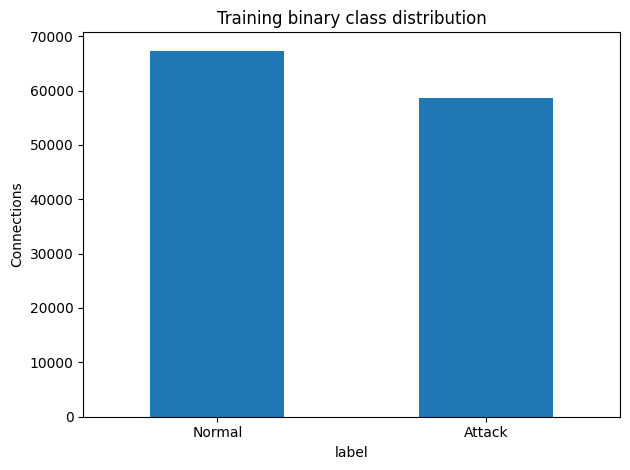

In [16]:
y_train.value_counts().sort_index().rename(index={0: 'Normal', 1: 'Attack'}).plot.bar(rot=0)
plt.title('Training binary class distribution')
plt.ylabel('Connections')
plt.tight_layout()
plt.savefig(FIG / '06_target.png', dpi=140, bbox_inches='tight')
plt.show()


## Interpretation and limitations
The training split has 67,343 normal and 58,630 attack rows. The final matrix has 120 features after one constant and one correlated feature are removed and categorical features are expanded. Scaling and column selection use training data only. The selected correlation rule needs later training-validation comparison; no performance gain is claimed.

For future cross-validation, refit all learned preprocessing within each training fold from raw data. These exports were prepared using the full official training split. NSL-KDD is a historical benchmark; this analysis does not establish modern live-network detection performance.